In [36]:
import pandas as pd
import numpy as np

print("Environment is ready")


Environment is ready


In [37]:
games = pd.read_csv("../data_raw/games.csv")
sales = pd.read_csv("../data_raw/vgsales.csv")


In [38]:
games = games.drop(columns=["Unnamed: 0"])



In [39]:
games.columns



Index(['Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist'],
      dtype='str')

In [40]:
games.isnull().sum()


Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [41]:
sales.isnull().sum()


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [42]:
games["Rating"] = games["Rating"].fillna(games["Rating"].median())


In [43]:
games["Team"] = games["Team"].fillna("unknown")
games["Summary"] = games["Summary"].fillna("unknown")


In [44]:
sales = sales.dropna(subset=["Year"])
sales["Year"] = sales["Year"].astype(int)


In [45]:
sales["Publisher"] = sales["Publisher"].fillna("unknown")


In [46]:
games.isnull().sum()


Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [47]:
sales.isnull().sum()


Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [48]:
games.to_csv("../data_cleaned/games_clean.csv", index=False)
sales.to_csv("../data_cleaned/vgsales_clean.csv", index=False)


In [49]:
top_rated_games = games.sort_values(by="Rating", ascending=False)[
    ["Title", "Rating", "Number of Reviews"]
].head(10)

top_rated_games


,Title,Rating,Number of Reviews
1252,Elden Ring: Shadow of the Erdtree,4.8,18
1322,Bloodborne: Game of the Year Edition,4.6,238
297,Bloodborne: The Old Hunters,4.6,266
43,Outer Wilds,4.6,1.8K
1286,Tokyo Necro,4.6,21
354,Disco Elysium: The Final Cut,4.6,1.1K
369,Outer Wilds,4.6,1.8K
428,Disco Elysium,4.6,1.1K
1138,Half-Life: Alyx,4.6,515
539,Umineko: When They Cry Chiru,4.6,324


In [50]:
top_developers = (
    games.groupby("Team")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_developers


Team
['Activision', 'FromSoftware']                     4.600
['Valve']                                          4.600
['Sony Computer Entertainment', 'FromSoftware']    4.600
['Konami Digital Entertainment']                   4.600
['Bay 12 Games', 'Kitfox Games']                   4.600
['ZA/UM']                                          4.600
['07th Expansion']                                 4.600
['Inlusio Interactive', 'IO Interactive']          4.600
['Mobius Digital', 'Annapurna Interactive']        4.575
['FromSoftware', 'Sony Computer Entertainment']    4.540
Name: Rating, dtype: float64

In [52]:
games[["Backlogs", "Wishlist"]].dtypes


Backlogs    str
Wishlist    str
dtype: object

In [60]:
games["Release Year"] = pd.to_datetime(
    games["Release Date"], errors="coerce"
).dt.year

release_trend = games["Release Year"].value_counts().sort_index()
release_trend


Release Year
1980.0      1
1982.0      1
1985.0      1
1986.0      4
1987.0      3
1988.0      5
1989.0      5
1990.0      6
1991.0     11
1992.0      6
1993.0     12
1994.0     11
1995.0     12
1996.0     15
1997.0     18
1998.0     16
1999.0     25
2000.0     15
2001.0     30
2002.0     22
2003.0     26
2004.0     37
2005.0     41
2006.0     32
2007.0     50
2008.0     44
2009.0     40
2010.0     58
2011.0     50
2012.0     60
2013.0     68
2014.0     59
2015.0     73
2016.0     75
2017.0     70
2018.0     77
2019.0     87
2020.0     74
2021.0     97
2022.0    132
2023.0     38
2024.0      1
2025.0      1
Name: count, dtype: int64

In [61]:
games["Rating"].describe()



count    1512.000000
mean        3.720040
std         0.530364
min         0.700000
25%         3.400000
50%         3.800000
75%         4.100000
max         4.800000
Name: Rating, dtype: float64

In [62]:
top_wishlisted = games.sort_values(
    by="Wishlist", ascending=False
)[["Title", "Wishlist"]].head(10)

top_wishlisted


,Title,Wishlist
951,Persona 3 Portable,995.0
401,Dark Souls II: Scholar of the First Sin,994.0
867,Dark Souls II: Scholar of the First Sin,994.0
121,Dark Souls II: Scholar of the First Sin,994.0
1087,Persona 2: Eternal Punishment,993.0
938,"Zero Escape: Nine Hours, Nine Persons, Nine Doors",991.0
173,Final Fantasy X,990.0
521,Rain World,987.0
502,Crash Bandicoot N. Sane Trilogy,986.0
235,Crash Bandicoot N. Sane Trilogy,986.0


In [ ]:
avg_plays_genre = (
    games.groupby("Genres")["Plays"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_plays_genre


Genres
['Fighting', 'Racing', 'Shooter']                                          986.0
['Adventure', 'Arcade', 'Platform', 'Shooter']                             907.0
['Adventure', 'Indie', 'Point-and-Click', 'RPG', 'Turn Based Strategy']    871.0
['Card & Board Game', 'Strategy']                                          847.0
['Adventure', 'Arcade', 'Indie', 'Platform', 'Puzzle', 'RPG']              753.0
['Music', 'Shooter']                                                       713.0
['Adventure', 'Point-and-Click', 'Shooter', 'Visual Novel']                547.0
['Shooter', 'Simulator']                                                   522.0
['Indie', 'RPG']                                                           478.5
['Indie', 'Point-and-Click', 'Puzzle', 'RPG', 'Simulator']                 471.0
Name: Plays, dtype: float64

In [ ]:
games.groupby("Team")["Plays"].sum().sort_values(ascending=False).head(10)


Team
['Intelligent Systems Co., Ltd.', 'Nintendo']                 2488.0
['Sega', 'Atlus']                                             2060.0
['Square Enix']                                               1942.0
['Grasshopper Manufacture', 'Victor Interactive Software']    1264.0
['Project Moon']                                              1179.0
['Nitroplus', 'JAST USA']                                     1006.0
['Team NINJA', 'Tecmo']                                        992.0
['Obsidian Entertainment', 'Sega']                             987.0
['Eat Sleep Play Inc.', 'Sony Computer Entertainment']         986.0
['Greg Lobanov', 'Finji']                                      984.0
Name: Plays, dtype: float64

In [ ]:
sales.head()
sales.describe()


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000
mean,8292.868194,2006.406443,0.265415,0.147554,0.078661,0.048325,0.540232
std,4792.669778,5.828981,0.821591,0.508766,0.311557,0.189885,1.565732
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4136.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8295.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12441.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [ ]:
sales.sort_values("Global_Sales", ascending=False)[
    ["Name", "Platform", "Year", "Global_Sales"]
].head(10)


,Name,Platform,Year,Global_Sales
0,Wii Sports,Wii,2006,82.74
1,Super Mario Bros.,NES,1985,40.24
2,Mario Kart Wii,Wii,2008,35.82
3,Wii Sports Resort,Wii,2009,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,31.37
5,Tetris,GB,1989,30.26
6,New Super Mario Bros.,DS,2006,30.01
7,Wii Play,Wii,2006,29.02
8,New Super Mario Bros. Wii,Wii,2009,28.62
9,Duck Hunt,NES,1984,28.31


In [ ]:
sales.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)


Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64

In [ ]:
sales.groupby("Publisher")["Global_Sales"] \
     .sum() \
     .sort_values(ascending=False) \
     .head(10)


Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64

In [ ]:
sales[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()


NA_Sales       4333.43
EU_Sales       2409.12
JP_Sales       1284.30
Other_Sales     789.01
dtype: float64

In [ ]:
sales.groupby("Platform")[["NA_Sales", "EU_Sales", "JP_Sales"]] \
     .sum() \
     .sort_values("NA_Sales", ascending=False) \
     .head(10)


,NA_Sales,EU_Sales,JP_Sales
Platform,,,
X360,594.33,278.01,12.30
PS2,572.92,332.63,137.54
Wii,497.37,264.35,68.28
PS3,388.90,340.47,79.21
DS,388.56,194.07,175.02
PS,334.71,212.38,139.78
GBA,184.12,74.59,46.56
XB,182.06,59.65,1.38
N64,138.91,41.03,33.76


In [ ]:
sales.groupby("Year")["Global_Sales"].sum().sort_index()


Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    419.31
2005    459.94
2006    521.04
2007    611.13
2008    678.90
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64

In [ ]:
yearly_sales = sales.groupby("Year")["Global_Sales"].sum()
yearly_sales


Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    419.31
2005    459.94
2006    521.04
2007    611.13
2008    678.90
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
sales = pd.read_csv("../data_cleaned/vgsales_clean.csv")


In [ ]:
yearly_sales = sales.groupby("Year")["Global_Sales"].sum()



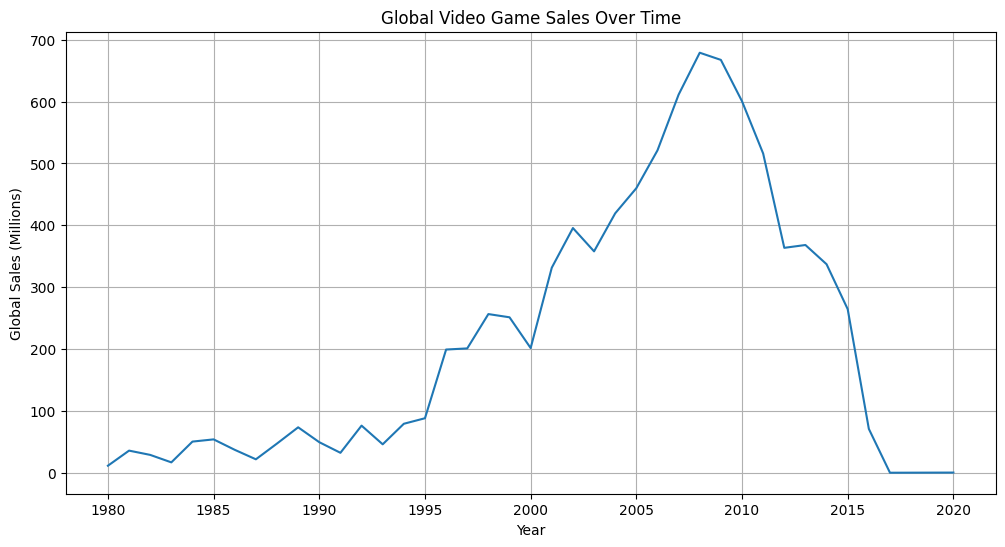

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(yearly_sales.index, yearly_sales.values)
plt.title("Global Video Game Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.grid(True)
plt.show()


In [ ]:
sales[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()


NA_Sales       4333.43
EU_Sales       2409.12
JP_Sales       1284.30
Other_Sales     789.01
dtype: float64

In [ ]:
platform_year_sales = (
    sales.groupby(["Year", "Platform"])["Global_Sales"]
    .sum()
    .reset_index()
)


In [ ]:
platform_trends = platform_year_sales.pivot(
    index="Year",
    columns="Platform",
    values="Global_Sales"
)


In [ ]:
top_platforms = sales.groupby("Platform")["Global_Sales"] \
                     .sum() \
                     .sort_values(ascending=False) \
                     .head(5) \
                     .index


In [ ]:
sales.head()


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
top_platforms = (
    sales.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_platforms


Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
Name: Global_Sales, dtype: float64

In [ ]:
platform_trends = (
    sales[sales["Platform"].isin(top_platforms.index)]
    .groupby(["Year", "Platform"])["Global_Sales"]
    .sum()
    .unstack()
)


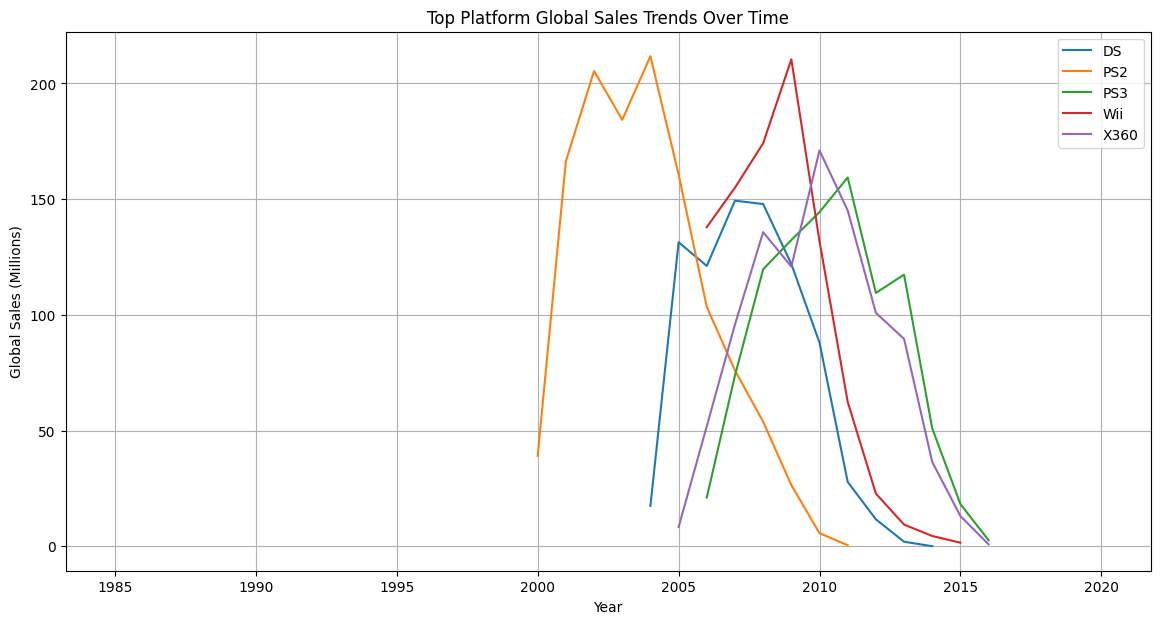

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for platform in platform_trends.columns:
    plt.plot(platform_trends.index, platform_trends[platform], label=platform)

plt.title("Top Platform Global Sales Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

import pandas as pd

df = pd.read_csv("../data_raw/vgsales.csv")

print(df.shape)
df.head()


(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:

df.to_csv("../data_cleaned/vgsales_clean.csv", index=False)


In [ ]:
import pandas as pd

games_df = pd.read_csv("../data_raw/games.csv")


In [ ]:

games_df = games_df.drop(columns=["Summary"])


In [ ]:

games_df.to_csv("../data_cleaned/games_clean.csv", index=False)

In [ ]:

games_df.to_csv("../data_cleaned/games_clean.csv", index=False)


In [ ]:
import pandas as pd


games_df = pd.read_csv("../data_cleaned/games_clean.csv")


In [ ]:

if "Unnamed: 0" in games_df.columns:
    games_df = games_df.drop(columns=["Unnamed: 0"])


In [ ]:

games_df.to_csv("../data_cleaned/games_clean.csv", index=False)


In [ ]:


import pandas as pd

games_df = pd.read_csv("../data_raw/games.csv")


games_df = games_df.drop(columns=["Summary", "Reviews"])


if "Unnamed: 0" in games_df.columns:
    games_df = games_df.drop(columns=["Unnamed: 0"])


games_df.to_csv("../data_cleaned/games_clean_sql.csv", index=False)


In [5]:
# Convert release_date to proper SQL date format
games_df["Release Date"] = pd.to_datetime(games_df["Release Date"], errors="coerce")


games_df.to_csv("../data_cleaned/games_clean_sql.csv", index=False)


In [7]:
print(games_df.columns)



Index(['Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Plays', 'Playing', 'Backlogs',
       'Wishlist'],
      dtype='str')


In [8]:
import re
import numpy as np

def clean_numeric(value):
    if pd.isna(value):
        return 0
    
    value = str(value).strip()
    
    # remove commas
    value = value.replace(",", "")
    
    # convert K to thousands
    if "K" in value:
        value = value.replace("K", "")
        return float(value) * 1000
    
    try:
        return float(value)
    except:
        return 0


In [20]:
print(games_df.columns)

Index(['title', 'release_date', 'team', 'rating', 'times_listed',
       'number_of_reviews', 'genres', 'plays', 'playing', 'backlogs',
       'wishlist'],
      dtype='str')


In [9]:
numeric_columns = [
    'Times Listed',
    'Number of Reviews',
    'Plays',
    'Playing',
    'Backlogs',
    'Wishlist'
]

for col in numeric_columns:
    games_df[col] = games_df[col].apply(clean_numeric)
    games_df[col] = games_df[col].astype(int)


In [10]:
games_df['Rating'] = pd.to_numeric(
    games_df['Rating'],
    errors='coerce'
).fillna(0)


In [11]:
games_df['Rating'] = games_df['Rating'].astype(float)


In [12]:
games_df['Release Date'] = pd.to_datetime(
    games_df['Release Date'],
    errors='coerce'
)

games_df['Release Date'] = games_df['Release Date'].fillna(pd.Timestamp("2000-01-01"))


In [13]:
games_df.columns = [
    'title',
    'release_date',
    'team',
    'rating',
    'times_listed',
    'number_of_reviews',
    'genres',
    'plays',
    'playing',
    'backlogs',
    'wishlist'
]


In [14]:
games_df.info()
games_df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   title              1512 non-null   str           
 1   release_date       1512 non-null   datetime64[us]
 2   team               1511 non-null   str           
 3   rating             1512 non-null   float64       
 4   times_listed       1512 non-null   int64         
 5   number_of_reviews  1512 non-null   int64         
 6   genres             1512 non-null   str           
 7   plays              1512 non-null   int64         
 8   playing            1512 non-null   int64         
 9   backlogs           1512 non-null   int64         
 10  wishlist           1512 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(6), str(3)
memory usage: 130.1 KB


title                0
release_date         0
team                 1
rating               0
times_listed         0
number_of_reviews    0
genres               0
plays                0
playing              0
backlogs             0
wishlist             0
dtype: int64

In [16]:
games_df.to_csv("../data_cleaned/games_clean_sql.csv", index=False)


In [18]:

games_df.columns = games_df.columns.str.strip()


In [21]:
games_df['rating'] = (
    games_df['rating']
    .astype(str)
    .str.replace('[^0-9.]', '', regex=True)
)

games_df['rating'] = pd.to_numeric(games_df['rating'], errors='coerce').fillna(0)


In [22]:
numeric_cols = [
    'times_listed',
    'number_of_reviews',
    'plays',
    'playing',
    'backlogs',
    'wishlist'
]

for col in numeric_cols:
    games_df[col] = (
        games_df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('K', '000', regex=False)
        .str.replace('[^0-9]', '', regex=True)
    )

    games_df[col] = pd.to_numeric(games_df[col], errors='coerce').fillna(0).astype(int)


In [23]:
games_df['release_date'] = pd.to_datetime(
    games_df['release_date'],
    errors='coerce'
)

games_df['release_date'] = games_df['release_date'].dt.strftime('%Y-%m-%d')


In [24]:
games_df['genres'] = games_df['genres'].astype(str)

games_df['genres'] = games_df['genres'].str.replace(r"[\[\]]", "", regex=True)
games_df['genres'] = games_df['genres'].str.replace("'", "")
games_df['genres'] = games_df['genres'].str.replace(",", "|")


In [25]:
import csv

games_df.to_csv(
    "../data_cleaned/games_clean_sql.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL
)


In [26]:
# Clean team column properly
games_df['team'] = games_df['team'].astype(str)

# Remove brackets
games_df['team'] = games_df['team'].str.replace(r"[\[\]]", "", regex=True)

# Remove single quotes
games_df['team'] = games_df['team'].str.replace("'", "")

# Replace comma with pipe
games_df['team'] = games_df['team'].str.replace(",", "|")


In [27]:
games_df.head()


,title,release_date,team,rating,times_listed,number_of_reviews,genres,plays,playing,backlogs,wishlist
0,Elden Ring,2022-02-25,Bandai Namco Entertainment| FromSoftware,4.5,3900,3900,Adventure| RPG,17000,3800,4600,4800
1,Hades,2019-12-10,Supergiant Games,4.3,2900,2900,Adventure| Brawler| Indie| RPG,21000,3200,6300,3600
2,The Legend of Zelda: Breath of the Wild,2017-03-03,Nintendo| Nintendo EPD Production Group No. 3,4.4,4300,4300,Adventure| RPG,30000,2500,5000,2600
3,Undertale,2015-09-15,tobyfox| 8-4,4.2,3500,3500,Adventure| Indie| RPG| Turn Based Strategy,28000,679,4900,1800
4,Hollow Knight,2017-02-24,Team Cherry,4.4,3000,3000,Adventure| Indie| Platform,21000,2400,8300,2300


In [28]:
games_df.to_csv(
    "../data_cleaned/games_final.csv",
    index=False
)


In [29]:
import pandas as pd

df = pd.read_csv("../data_cleaned/games_final.csv")
print("Total rows in CSV:", len(df))


Total rows in CSV: 1512
